In [ ]:
import numpy as np
import pandas as pd
import sklearn.metrics as metrics
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from matplotlib import pyplot
import imblearn
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
from sklearn import datasets
from sklearn.preprocessing import LabelBinarizer

In [ ]:
df = pd.read_excel("data-pregnant.xlsx")
df

,V012,V024,V025,V106,V130,V190,V201,V218,V225,V404,V701,V714,V730,mass,Occupation,Toiletfacility,Drinkingwater,bmi1
0,1,1,2,1,1,1,0,0,1,0,1,0,1,0,3,2,1,2
1,2,1,2,2,1,1,0,0,1,0,2,0,1,0,1,2,2,2
2,2,1,2,2,1,2,0,0,1,0,3,0,1,0,3,2,1,1
3,4,1,2,3,2,3,1,1,1,0,3,1,2,1,3,1,1,2
4,3,1,2,2,1,2,1,1,1,0,1,1,1,1,2,2,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1124,2,8,1,2,1,5,1,1,1,0,2,0,2,1,4,2,2,3
1125,3,8,1,1,1,4,1,1,1,0,1,1,2,1,2,1,1,3
1126,2,8,1,1,1,3,1,1,1,0,1,1,1,1,3,1,1,2
1127,4,8,1,3,1,5,1,1,1,1,3,0,2,1,3,1,1,2


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1129 entries, 0 to 1128
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   V012            1129 non-null   int64
 1   V024            1129 non-null   int64
 2   V025            1129 non-null   int64
 3   V106            1129 non-null   int64
 4   V130            1129 non-null   int64
 5   V190            1129 non-null   int64
 6   V201            1129 non-null   int64
 7   V218            1129 non-null   int64
 8   V225            1129 non-null   int64
 9   V404            1129 non-null   int64
 10  V701            1129 non-null   int64
 11  V714            1129 non-null   int64
 12  V730            1129 non-null   int64
 13  mass            1129 non-null   int64
 14  Occupation      1129 non-null   int64
 15  Toiletfacility  1129 non-null   int64
 16  Drinkingwater   1129 non-null   int64
 17  bmi1            1129 non-null   int64
dtypes: int64(18)
memory usage: 1

In [ ]:
# Standardization (FT1)
from sklearn.preprocessing import StandardScaler  # import the standard scaler
FT1 = StandardScaler()  # create the scaler object
FT1_data = FT1.fit_transform(df)  # scale all columns to similar ranges
FT1_df = pd.DataFrame(FT1_data, columns=df.columns)  # turn scaled data into a DataFrame
print(FT1_df.head())  # show the first few scaled rows

# Min-Max Scaling (FT2)
from sklearn.preprocessing import MinMaxScaler  # import min-max scaler
FT2 = MinMaxScaler()  # create the min-max scaler
FT2_data = FT2.fit_transform(df)  # scale values between 0 and 1
FT2_df = pd.DataFrame(FT2_data, columns=df.columns)  # convert scaled data into a DataFrame
FT2_df.head()  # preview the min-max scaled data

# Log Scaling (FT3)
from sklearn.preprocessing import FunctionTransformer  # import a custom transformer
import numpy as np  # import NumPy for log scaling
transformer = FunctionTransformer(np.log1p)  # create a log(x + 1) transformer
t1 = transformer.transform(df)  # apply log scaling to the data
print(t1)  # show the log-scaled values

# Robust Scaling (FT4)
from sklearn.preprocessing import RobustScaler  # import robust scaler
FT4 = RobustScaler()  # create the robust scaler
FT4_data = FT4.fit_transform(df)  # scale data using median and spread
FT4_df = pd.DataFrame(FT4_data, columns=df.columns)  # convert scaled data into a DataFrame
print(FT4_df.head())  # show the first few robust scaled rows

       V012      V024      V025      V106      V130      V190      V201  \
0 -1.185620 -1.515422  0.740741 -1.080109 -0.301366 -1.402128 -1.058420   
1 -0.257350 -1.515422  0.740741  0.190144 -0.301366 -1.402128 -1.058420   
2 -0.257350 -1.515422  0.740741  0.190144 -0.301366 -0.700132 -1.058420   
3  1.599189 -1.515422  0.740741  1.460397  3.318228  0.001865  0.390012   
4  0.670919 -1.515422  0.740741  0.190144 -0.301366 -0.700132  0.390012   

       V218      V225      V404      V701      V714      V730      mass  \
0 -0.909814  0.577009 -0.253161 -0.649743 -0.698200 -0.854752 -1.355243   
1 -0.909814  0.577009 -0.253161  0.422713 -0.698200 -0.854752 -1.355243   
2 -0.909814  0.577009 -0.253161  1.495169 -0.698200 -0.854752 -1.355243   
3  0.313019  0.577009 -0.253161  1.495169  1.432254  1.030043  0.737875   
4  0.313019  0.577009 -0.253161 -0.649743  1.432254 -0.854752  0.737875   

   Occupation  Toiletfacility  Drinkingwater      bmi1  
0    0.404906        0.749366      -0.511

In [ ]:
df.info()  # check the data types and missing values again

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1129 entries, 0 to 1128
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   V012            1129 non-null   int64
 1   V024            1129 non-null   int64
 2   V025            1129 non-null   int64
 3   V106            1129 non-null   int64
 4   V130            1129 non-null   int64
 5   V190            1129 non-null   int64
 6   V201            1129 non-null   int64
 7   V218            1129 non-null   int64
 8   V225            1129 non-null   int64
 9   V404            1129 non-null   int64
 10  V701            1129 non-null   int64
 11  V714            1129 non-null   int64
 12  V730            1129 non-null   int64
 13  mass            1129 non-null   int64
 14  Occupation      1129 non-null   int64
 15  Toiletfacility  1129 non-null   int64
 16  Drinkingwater   1129 non-null   int64
 17  bmi1            1129 non-null   int64
dtypes: int64(18)
memory usage: 1

In [ ]:
# FT4_df.head()  # this would preview the robust scaled data
y = FT4_df.bmi1  # use bmi1 as the target variable
x = FT4_df.drop('bmi1', axis=1)  # use the other columns as features

In [ ]:
y  # display the target column

0       0.0
1       0.0
2      -1.0
3       0.0
4       0.0
       ... 
1124    1.0
1125    1.0
1126    0.0
1127    0.0
1128   -1.0
Name: bmi1, Length: 1129, dtype: float64

In [ ]:
x  # display the feature columns

,V012,V024,V025,V106,V130,V190,V201,V218,V225,V404,V701,V714,V730,mass,Occupation,Toiletfacility,Drinkingwater
0,-0.5,-0.75,0.0,-1.0,0.0,-1.0,-1.0,-1.0,0.0,0.0,-1.0,0.0,0.0,-1.0,0.0,0.0,0.0
1,0.0,-0.75,0.0,0.0,0.0,-1.0,-1.0,-1.0,0.0,0.0,0.0,0.0,0.0,-1.0,-2.0,0.0,1.0
2,0.0,-0.75,0.0,0.0,0.0,-0.5,-1.0,-1.0,0.0,0.0,1.0,0.0,0.0,-1.0,0.0,0.0,0.0
3,1.0,-0.75,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,-1.0,0.0
4,0.5,-0.75,0.0,0.0,0.0,-0.5,0.0,0.0,0.0,0.0,-1.0,1.0,0.0,0.0,-1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1124,0.0,1.00,-1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
1125,0.5,1.00,-1.0,-1.0,0.0,0.5,0.0,0.0,0.0,0.0,-1.0,1.0,1.0,0.0,-1.0,-1.0,0.0
1126,0.0,1.00,-1.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,1.0,0.0,0.0,0.0,-1.0,0.0
1127,1.0,1.00,-1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,-1.0,0.0


In [ ]:
y = LabelEncoder().fit_transform(y)  # change target labels into numbers
oversample = SMOTE()  # create SMOTE to balance classes
x, y = oversample.fit_resample(x, y)  # make class counts more balanced
counter = Counter(y)  # count samples in each class
for k, v in counter.items():  # loop through each class count
  per = v / len(y) * 100  # calculate class percentage
  print('class=%d, count=%d, percentage=%.3f%%' % (k, v, per))  # print class distribution

çlass=1, count=664, percentage=33.333%
çlass=0, count=664, percentage=33.333%
çlass=2, count=664, percentage=33.333%


C:\Users\ASUS\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\ASUS\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\ASUS\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\ASUS\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^

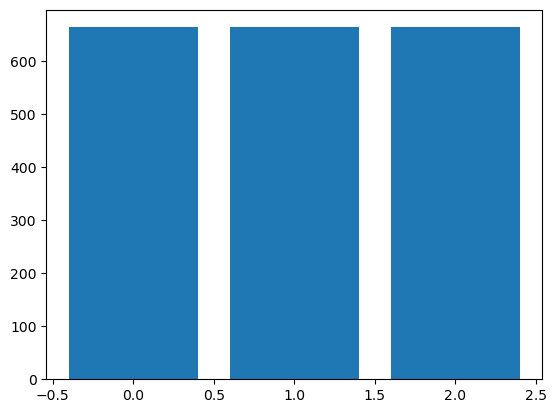

In [ ]:
pyplot.bar(counter.keys(), counter.values())  # draw a bar chart for class counts
pyplot.show()  # show the chart

In [ ]:
from sklearn.model_selection import train_test_split  # import the train-test split tool
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=101)  # split data into training and testing sets
x_train.head()  # preview the training features
x_train.shape  # check the training data shape

(1394, 17)

In [ ]:
x_test.head()  # preview the testing features
x_test.shape  # check the testing data shape

(598, 17)

In [ ]:
# logistic regression
from sklearn.linear_model import LogisticRegression  # import logistic regression
Lr = LogisticRegression()  # create the model
Lr.fit(x_train, y_train)  # train the model on the training data

# Generate predictions for both test and training data
predictions = Lr.predict(x_test)  # predict labels for the test set
train_predictions = Lr.predict(x_train)  # predict labels for the training set

from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools

# Train performance
print("=== Training Performance ===")  # print training results heading
print(classification_report(y_train, train_predictions, digits=4))  # show training metrics
print(confusion_matrix(y_train, train_predictions))  # show training confusion matrix
# test performance
print("=== Test Performance ===")  # print test results heading
print(classification_report(y_test, predictions, digits=4))  # show test metrics
print(confusion_matrix(y_test, predictions))  # show test confusion matrix
y_score = Lr.fit(x_train, y_train).predict_proba(x_test)  # get prediction probabilities for ROC work

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, predictions)  # measure agreement between true and predicted labels

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(Lr, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

=== Training Performance ===
              precision    recall  f1-score   support

           0     0.5817    0.6532    0.6154       447
           1     0.4732    0.3427    0.3975       464
           2     0.6295    0.7246    0.6737       483

    accuracy                         0.5746      1394
   macro avg     0.5615    0.5735    0.5622      1394
weighted avg     0.5621    0.5746    0.5631      1394

[[292 104  51]
 [150 159 155]
 [ 60  73 350]]
=== Test Performance ===
              precision    recall  f1-score   support

           0     0.5746    0.6037    0.5888       217
           1     0.4632    0.3150    0.3750       200
           2     0.5684    0.7348    0.6410       181

    accuracy                         0.5468       598
   macro avg     0.5354    0.5512    0.5349       598
weighted avg     0.5355    0.5468    0.5331       598

[[131  43  43]
 [ 79  63  58]
 [ 18  30 133]]
Cross Validation Scores are [0.575      0.5        0.49246231 0.55276382 0.54773869 0.587939

# Decision Tree

In [ ]:
# Decision Tree
from sklearn.tree import DecisionTreeClassifier  # import decision tree model
dtree = DecisionTreeClassifier()  # create the model
dtree.fit(x_train, y_train)  # train the model
predictions = dtree.predict(x_test)  # predict labels for the test set
from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools
print(classification_report(y_test, predictions, digits=4))  # show test metrics
print(confusion_matrix(y_test, predictions))  # show test confusion matrix
y_score = dtree.fit(x_train, y_train).predict_proba(x_test)  # get prediction probabilities

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, predictions)  # calculate agreement score

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(dtree, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

              precision    recall  f1-score   support

           0     0.6274    0.6129    0.6200       217
           1     0.5714    0.5000    0.5333       200
           2     0.6825    0.7956    0.7347       181

    accuracy                         0.6304       598
   macro avg     0.6271    0.6362    0.6294       598
weighted avg     0.6253    0.6304    0.6257       598

[[133  54  30]
 [ 63 100  37]
 [ 16  21 144]]
Cross Validation Scores are [0.63       0.635      0.63316583 0.65829146 0.63819095 0.60301508
 0.64321608 0.65326633 0.67336683 0.66834171 0.62       0.66
 0.61809045 0.64321608 0.65829146 0.66834171 0.68341709 0.65326633
 0.63819095 0.73869347 0.7        0.6        0.65326633 0.66331658
 0.63316583 0.65829146 0.64824121 0.66331658 0.69849246 0.63316583]
Average Cross Validation score :0.6522872696817419


# Random Forest

In [ ]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier  # import random forest model
rfc = RandomForestClassifier(n_estimators=100)  # create the model with 100 trees
rfc.fit(x_train, y_train)  # train the model
predictions = rfc.predict(x_test)  # predict labels for the test set
from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools
print(classification_report(y_test, predictions, digits=4))  # show test metrics
print(confusion_matrix(y_test, predictions))  # show test confusion matrix
y_score = rfc.fit(x_train, y_train).predict_proba(x_test)  # get prediction probabilities

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, predictions)  # calculate agreement score

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(rfc, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

              precision    recall  f1-score   support

           0     0.7812    0.6912    0.7335       217
           1     0.6468    0.7050    0.6746       200
           2     0.8298    0.8619    0.8455       181

    accuracy                         0.7475       598
   macro avg     0.7526    0.7527    0.7512       598
weighted avg     0.7510    0.7475    0.7477       598

[[150  60   7]
 [ 34 141  25]
 [  8  17 156]]
Cross Validation Scores are [0.805      0.745      0.7638191  0.73869347 0.71356784 0.75879397
 0.79899497 0.76884422 0.77386935 0.74371859 0.76       0.79
 0.77889447 0.75376884 0.74874372 0.77889447 0.75879397 0.78894472
 0.71356784 0.74371859 0.76       0.77       0.75879397 0.73869347
 0.66834171 0.8040201  0.80904523 0.71859296 0.7839196  0.76884422]
Average Cross Validation score :0.7601959798994975


# K- nearest neighbor

In [ ]:
# K- nearest neighbor
from sklearn.neighbors import KNeighborsClassifier  # import KNN model
KN = KNeighborsClassifier()  # create the model
KN.fit(x_train, y_train)  # train the model
predictions = KN.predict(x_test)  # predict labels for the test set
from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools
print(classification_report(y_test, predictions, digits=4))  # show test metrics
print(confusion_matrix(y_test, predictions))  # show test confusion matrix
y_score = KN.fit(x_train, y_train).predict_proba(x_test)  # get prediction probabilities

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, predictions)  # calculate agreement score

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(KN, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

              precision    recall  f1-score   support

           0     0.6292    0.7742    0.6942       217
           1     0.6437    0.2800    0.3902       200
           2     0.6557    0.8840    0.7529       181

    accuracy                         0.6421       598
   macro avg     0.6429    0.6461    0.6125       598
weighted avg     0.6421    0.6421    0.6103       598

[[168  24  25]
 [ 85  56  59]
 [ 14   7 160]]
Cross Validation Scores are [0.64       0.7        0.71859296 0.63819095 0.64321608 0.67336683
 0.65326633 0.71859296 0.70351759 0.70854271 0.65       0.725
 0.69346734 0.66331658 0.66834171 0.69346734 0.65829146 0.69346734
 0.65326633 0.71356784 0.71       0.655      0.71859296 0.64824121
 0.66834171 0.69346734 0.69346734 0.64824121 0.65326633 0.73366834]
Average Cross Validation score :0.6810586264656615


# GaussianNB

In [ ]:
# GaussianNB
from sklearn.naive_bayes import GaussianNB  # import Gaussian Naive Bayes model
NB = GaussianNB()  # create the model
NB.fit(x_train, y_train)  # train the model
predictions = NB.predict(x_test)  # predict labels for the test set
from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools
print(classification_report(y_test, predictions, digits=4))  # show test metrics
print(confusion_matrix(y_test, predictions))  # show test confusion matrix
y_score = NB.fit(x_train, y_train).predict_proba(x_test)  # get prediction probabilities

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, predictions)  # calculate agreement score

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(NB, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

              precision    recall  f1-score   support

           0     0.5284    0.5576    0.5426       217
           1     0.3981    0.2050    0.2706       200
           2     0.5000    0.7348    0.5951       181

    accuracy                         0.4933       598
   macro avg     0.4755    0.4991    0.4694       598
weighted avg     0.4762    0.4933    0.4675       598

[[121  37  59]
 [ 85  41  74]
 [ 23  25 133]]
Cross Validation Scores are [0.56       0.495      0.45728643 0.48241206 0.52763819 0.55276382
 0.54773869 0.46733668 0.50251256 0.54271357 0.49       0.545
 0.49748744 0.46733668 0.55778894 0.46733668 0.52763819 0.54773869
 0.47236181 0.54271357 0.465      0.48       0.47738693 0.52763819
 0.50251256 0.5678392  0.54773869 0.53266332 0.51758794 0.51256281]
Average Cross Validation score :0.5127244556113902


# support vector machine

In [ ]:
# support vector machine
from sklearn.svm import LinearSVC  # import linear SVM model
classifier = LinearSVC()  # create the model
classifier.fit(x_train, y_train)  # train the model
y_predict = classifier.predict(x_test)  # predict labels for the test set
from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools
print(classification_report(y_test, y_predict, digits=4))  # show test metrics
print(confusion_matrix(y_test, y_predict))  # show test confusion matrix
y_score = classifier.fit(x_train, y_train).decision_function(x_test)  # get decision scores

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, y_predict)  # calculate agreement score

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(classifier, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

              precision    recall  f1-score   support

           0     0.5573    0.6498    0.6000       217
           1     0.5116    0.2200    0.3077       200
           2     0.5521    0.7901    0.6500       181

    accuracy                         0.5485       598
   macro avg     0.5404    0.5533    0.5192       598
weighted avg     0.5405    0.5485    0.5174       598

[[141  28  48]
 [ 88  44  68]
 [ 24  14 143]]
Cross Validation Scores are [0.575      0.505      0.54773869 0.53768844 0.54271357 0.60301508
 0.55778894 0.50251256 0.56281407 0.54773869 0.52       0.59
 0.55778894 0.50753769 0.54271357 0.49246231 0.56281407 0.60301508
 0.53266332 0.57286432 0.53       0.5        0.53768844 0.58291457
 0.5678392  0.58291457 0.57286432 0.52261307 0.54773869 0.58291457]
Average Cross Validation score :0.54971189279732


In [ ]:
# AdaBoostClassifier  # start the AdaBoost section

In [ ]:
# AdaBoostClassifier
from sklearn.ensemble import AdaBoostClassifier  # import AdaBoost model
abc = AdaBoostClassifier(n_estimators=50, learning_rate=1)  # create the model
model = abc.fit(x_train, y_train)  # train the model
y_pred = model.predict(x_test)  # predict labels for the test set
from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools
print(classification_report(y_test, y_pred, digits=4))  # show test metrics
print(confusion_matrix(y_test, y_pred))  # show test confusion matrix
y_score = abc.fit(x_train, y_train).predict_proba(x_test)  # get prediction probabilities

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, predictions)  # calculate agreement score

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(abc, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

              precision    recall  f1-score   support

           0     0.5860    0.5806    0.5833       217
           1     0.5540    0.3850    0.4543       200
           2     0.6025    0.8122    0.6918       181

    accuracy                         0.5853       598
   macro avg     0.5808    0.5926    0.5765       598
weighted avg     0.5803    0.5853    0.5730       598

[[126  46  45]
 [ 71  77  52]
 [ 18  16 147]]
Cross Validation Scores are [0.605      0.55       0.55778894 0.5678392  0.56281407 0.59798995
 0.65829146 0.57788945 0.61809045 0.63819095 0.55       0.61
 0.61306533 0.52763819 0.57788945 0.59798995 0.5879397  0.61306533
 0.6080402  0.63316583 0.585      0.605      0.59798995 0.59798995
 0.57286432 0.58291457 0.5879397  0.59798995 0.58291457 0.63819095]
Average Cross Validation score :0.5933827470686768


# GradientBoostingClassifier

In [ ]:
# GradientBoostingClassifier
from sklearn.ensemble import GradientBoostingClassifier  # import gradient boosting model
GB = GradientBoostingClassifier()  # create the model
model = GB.fit(x_train, y_train)  # train the model
predictions = model.predict(x_test)  # predict labels for the test set
from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools
print(classification_report(y_test, predictions, digits=4))  # show test metrics
print(confusion_matrix(y_test, predictions))  # show test confusion matrix
y_score = GB.fit(x_train, y_train).predict_proba(x_test)  # get prediction probabilities

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, predictions)  # calculate agreement score

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(GB, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

              precision    recall  f1-score   support

           0     0.7011    0.5945    0.6434       217
           1     0.5896    0.6250    0.6068       200
           2     0.7178    0.8011    0.7572       181

    accuracy                         0.6672       598
   macro avg     0.6695    0.6735    0.6691       598
weighted avg     0.6689    0.6672    0.6656       598

[[129  61  27]
 [ 45 125  30]
 [ 10  26 145]]
Cross Validation Scores are [0.73       0.65       0.65829146 0.70351759 0.66834171 0.70351759
 0.71356784 0.65326633 0.73366834 0.68844221 0.67       0.73
 0.73366834 0.6281407  0.68341709 0.68341709 0.70351759 0.70351759
 0.67839196 0.68844221 0.685      0.68       0.68844221 0.68341709
 0.6080402  0.73366834 0.67839196 0.74874372 0.73366834 0.74371859]
Average Cross Validation score :0.6929405360134004


# XGBoost

In [ ]:
# XGBoost
from numpy import loadtxt  # import loadtxt from NumPy
from xgboost import XGBClassifier  # import XGBoost model
XGB = XGBClassifier()  # create the model
model = XGB.fit(x_train, y_train)  # train the model
predictions = model.predict(x_test)  # predict labels for the test set
from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools
print(classification_report(y_test, predictions, digits=4))  # show test metrics
print(confusion_matrix(y_test, predictions))  # show test confusion matrix
y_score = XGB.fit(x_train, y_train).predict_proba(x_test)  # get prediction probabilities

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, predictions)  # calculate agreement score

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(XGB, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

              precision    recall  f1-score   support

           0     0.7448    0.6590    0.6993       217
           1     0.6193    0.6750    0.6459       200
           2     0.8085    0.8398    0.8238       181

    accuracy                         0.7191       598
   macro avg     0.7242    0.7246    0.7230       598
weighted avg     0.7221    0.7191    0.7191       598

[[143  63  11]
 [ 40 135  25]
 [  9  20 152]]
Cross Validation Scores are [0.75       0.685      0.71356784 0.72361809 0.71356784 0.70854271
 0.76884422 0.69346734 0.7638191  0.69849246 0.7        0.775
 0.75879397 0.72361809 0.72361809 0.69346734 0.75376884 0.73366834
 0.67336683 0.71859296 0.735      0.73       0.70351759 0.7638191
 0.70351759 0.75879397 0.72864322 0.73366834 0.74874372 0.74371859]
Average Cross Validation score :0.7274078726968176
